## ***Initials***

In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from collections import defaultdict
from geopy.distance import geodesic

## ***Help Functions***

In [36]:
import matplotlib.pyplot as plt

def plot_histogram(df, column, bins=20):

    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame")

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=bins, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [2]:
def soft_spatial_overlap(top_a, top_b, centroid_dict, threshold_km=1.0):
    matches = 0
    for a in top_a:
        coord_a = centroid_dict.get(a)
        if coord_a is None:
            continue
        for b in top_b:
            coord_b = centroid_dict.get(b)
            if coord_b is None:
                continue
            if geodesic(coord_a, coord_b).km <= threshold_km:
                matches += 1
                break  # Only one match per A
    return matches / len(top_a)

In [3]:
def spatial_similarity(df1, df2, centroid_dict):

    scores = []

    for i in range(len(df1)):
        top_a = [df1.loc[i, 'Top1'], df1.loc[i, 'Top2'], df1.loc[i, 'Top3']]
        top_b = [df2.loc[i, 'Top1'], df2.loc[i, 'Top2'], df2.loc[i, 'Top3']]
        
        score = soft_spatial_overlap(top_a, top_b, centroid_dict, threshold_km=1.0)
        scores.append(score)

    mean_soft_overlap = sum(scores) / len(scores)
    print(f"Mean soft spatial overlap@3 (within 1 km): {mean_soft_overlap:.4f}")

In [4]:
# Extract Top3 communities for a NACE code from each file
def get_communities(df, code):
    row = df[df['NACE Code'] == code]
    if row.empty:
        return set()
    return set(row[['Top1', 'Top2', 'Top3']].values.flatten())

In [5]:
# Compute Jaccard scores
def jaccard(a, b):
    return len(a & b) / len(a | b) if a | b else None

## ***Load the Data***

In [6]:
# Load CSV files
df_supervised = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\1. Supervised Approach\\2. Approach 2 (won)\\Extracted CSV Files\\top10.csv")
df_unsupervised = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\2. Unsupervised Approach\\2. Approach 2 (won)\\Extracted CSV Files\\top10.csv")
df_semi_supervised = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\3. Semi-Supervised Approach\\1. Approach 1 (won)\\Extracted CSV Files\\top10.csv")

In [7]:
# Get union of all NACE codes across files
nace_codes = sorted(set(df_supervised['NACE Code']).union(df_unsupervised['NACE Code']).union(df_semi_supervised['NACE Code']))
print(f"length of NACE codes: {len(nace_codes)}")

length of NACE codes: 306


## ***Agreement Count per NACE Code***

We make a file that contains: for every NACE, all the candidates contained in the 3 'top3.csv' files, and their frequency. This way we can see for every NACE the most frequent recommendations

In [14]:
# Initialize results list
agreement_stats = []

for code in nace_codes:

    # Get the top-3 from each approach
    sup_row = df_supervised[df_supervised['NACE Code'] == code]
    unsup_row = df_unsupervised[df_unsupervised['NACE Code'] == code]
    ssl_row = df_semi_supervised[df_semi_supervised['NACE Code'] == code]

    sup_list = list(sup_row[['Top1', 'Top2', 'Top3']].values.flatten()) if not sup_row.empty else []
    unsup_list = list(unsup_row[['Top1', 'Top2', 'Top3']].values.flatten()) if not unsup_row.empty else []
    ssl_list = list(ssl_row[['Top1', 'Top2', 'Top3']].values.flatten()) if not ssl_row.empty else []

    # Remove missing or NaN
    all_suggestions = [x for x in sup_list + unsup_list + ssl_list if pd.notna(x)]

    # Store which communities were suggested how many times
    community_counts = Counter(all_suggestions)

    # Get Top1, Top2, Top3 based on frequency (and alphabetical tie-break)
    all_ranked = sorted(community_counts.items(), key=lambda x: (-x[1], x[0]))
    suggestions_str = ', '.join(f"{k} ({v})" for k, v in all_ranked)

    # Append the results for this NACE code
    agreement_stats.append({
        "NACE Code": code,
        "Total Suggestions": len(all_suggestions),
        "Unique Suggestions": len(set(all_suggestions)),
        "Overlap Count": len(all_suggestions) - len(set(all_suggestions)),
        "All Suggestions": suggestions_str
    })


# Convert to DataFrame and sort by overlap
agreement_df = pd.DataFrame(agreement_stats).sort_values(by="NACE Code", ascending=True)

In [15]:
agreement_df.head()

,NACE Code,Total Suggestions,Unique Suggestions,Overlap Count,All Suggestions
0,1.13,8,6,2,"Kato Lehonia (2), Metamorfosi (2), Agioi Anarg..."
1,1.30,9,6,3,"Agia Paraskeui (3), Agios Vasilios (2), Agia K..."
2,1.49,8,4,4,"Dimini (3), Nees Pagases (3), Melissatika (1),..."
3,1.61,9,5,4,"Nees Pagases (3), Dimitriada (2), Epta Platani..."
4,2.40,9,5,4,"Metamorfosi (3), Analipsi (2), Asteria Agrias ..."


In [16]:
# Save file
agreement_df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\4. Ensembling of Approaches\\Extracted CSV Files\\top3_agreement_analysis.csv", index=False)

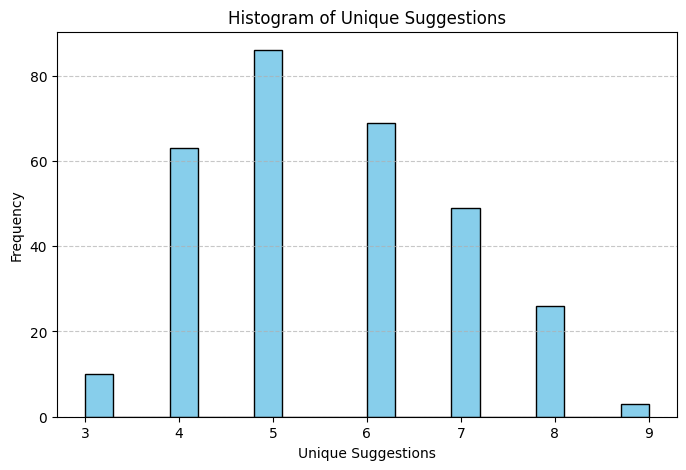

In [35]:
plot_histogram(agreement_df, column="Unique Suggestions")

## ***Venn Diagrams***

This is a visualization technique that shows the overlapping candidates in the 3 different 'top3.csv' files

In [14]:
# Loop and create Venns
for code in nace_codes:
    sup_set = get_communities(df_supervised, code)
    unsup_set = get_communities(df_unsupervised, code)
    ssl_set = get_communities(df_semi_supervised, code)

    # Skip completely empty ones
    if not (sup_set or unsup_set or ssl_set):
        continue

    # Plot Venn diagram
    plt.figure(figsize=(8, 6))
    venn3([sup_set, unsup_set, ssl_set],
          set_labels=("Supervised", "Unsupervised", "Semi-supervised"))
    plt.title(f"Top-3 Overlap for NACE Code {code}")
    plt.tight_layout()
    code_str = str(code).replace('.', '_')
    plt.savefig(f"C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\4. Ensembling of Approaches\\Outputs\\Venn Diagrams_new\\venn_nace_{code_str}.png", dpi=300)
    plt.close()

c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")
c:\Users\Giorgos\anaconda3\envs\mac

## ***Jaccard Similarity***

It measures the ***similarity between 2 sets***, gives a percentage number. This is done ***element-wise*** and ***does not capture the spatial similarity***

In [11]:
jaccard_stats = []

for code in nace_codes:
    sup_row = df_supervised[df_supervised['NACE Code'] == code]
    unsup_row = df_unsupervised[df_unsupervised['NACE Code'] == code]
    ssl_row = df_semi_supervised[df_semi_supervised['NACE Code'] == code]

    # Extract Top-3 sets
    sup_set = set(sup_row[['Top1', 'Top2', 'Top3']].values.flatten()) if not sup_row.empty else set()
    unsup_set = set(unsup_row[['Top1', 'Top2', 'Top3']].values.flatten()) if not unsup_row.empty else set()
    ssl_set = set(ssl_row[['Top1', 'Top2', 'Top3']].values.flatten()) if not ssl_row.empty else set()

    # Clean NaNs
    sup_set = {x for x in sup_set if pd.notna(x)}
    unsup_set = {x for x in unsup_set if pd.notna(x)}
    ssl_set = {x for x in ssl_set if pd.notna(x)}

    # Compute the Jaccard scores
    j_su = jaccard(sup_set, unsup_set)
    j_ssl = jaccard(sup_set, ssl_set)
    j_ul = jaccard(unsup_set, ssl_set)

    # Append the results for this NACE code
    jaccard_stats.append({
        "NACE Code": code,
        "Jaccard(Supervised, Unsupervised)": j_su,
        "Jaccard(Supervised, SSL)": j_ssl,
        "Jaccard(Unsupervised, SSL)": j_ul,
    })

jaccard_df = pd.DataFrame(jaccard_stats)
jaccard_df = jaccard_df.sort_values(by="NACE Code")

In [12]:
jaccard_df.head()

,NACE Code,"Jaccard(Supervised, Unsupervised)","Jaccard(Supervised, SSL)","Jaccard(Unsupervised, SSL)"
0,1.13,0.0,0.666667,0.000000
1,1.30,0.2,0.500000,0.200000
2,1.49,0.5,0.666667,0.666667
3,1.61,0.2,1.000000,0.200000
4,2.40,0.2,1.000000,0.200000


In [ ]:
# Save file
jaccard_df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\4. Ensembling of Approaches\\Outputs\\jaccard_similarities.csv", index=False)

In [37]:
def barchart_jaccard_similarities(mean_j_s_u, mean_j_u_ssl, mean_j_s_ssl):
    
    # Data
    pairs = [
        "Supervised vs Unsupervised",
        "Supervised vs SSL",
        "Unsupervised vs SSL"
    ]
    values = [mean_j_s_u, mean_j_u_ssl, mean_j_s_ssl]

    # Plot
    plt.figure(figsize=(7,5))
    bars = plt.bar(pairs, values, color="skyblue", edgecolor="black")

    # Add value labels above bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{value:.3f}", ha='center', va='bottom', fontsize=10)

    # Titles and labels
    plt.title("Mean Jaccard Similarities Between Approaches")
    plt.ylabel("Mean Jaccard Similarity")
    plt.ylim(0, 0.6)  # adjust to make values clearer

    plt.tight_layout()
    plt.show()

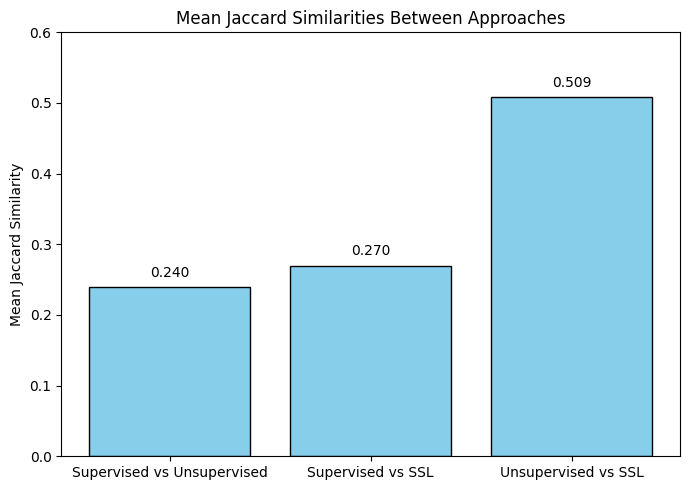

In [39]:
mean_j_s_u = jaccard_df["Jaccard(Supervised, Unsupervised)"].mean()
mean_j_u_ssl = jaccard_df["Jaccard(Unsupervised, SSL)"].mean()
mean_j_s_ssl = jaccard_df["Jaccard(Supervised, SSL)"].mean()

barchart_jaccard_similarities(mean_j_s_u, mean_j_u_ssl, mean_j_s_ssl)

In the old approach i had

- Mean Jaccard(Supervised, Unsupervised): 0.4694
- Mean Jaccard(Supervised, SSL): 0.5742
- Mean Jaccard(Unsupervised, SSL): 0.4644

the fall off could be explained by the fact that: in general the locaitons near the center are preferred. Before, the spatial units were larger (municipal commumities) so I could get 1/2 max of them. Now i have multiple location just for the Municipal Community of Volos, so i get more possible suggestions and more diverse --> lower set similarity of sets

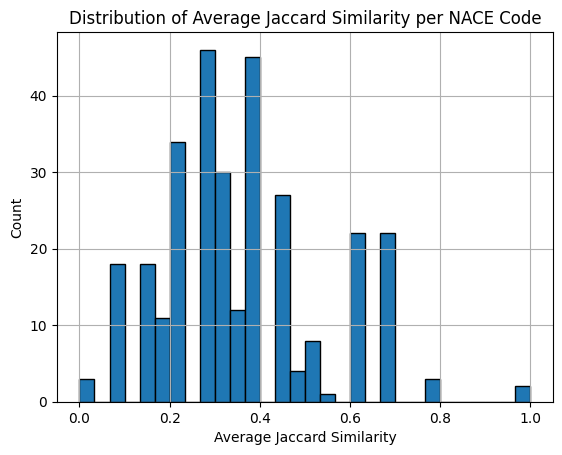

In [19]:
jaccard_df["Avg Jaccard"] = jaccard_df[
    ["Jaccard(Supervised, Unsupervised)", "Jaccard(Supervised, SSL)", "Jaccard(Unsupervised, SSL)"]
].mean(axis=1)

plt.hist(jaccard_df["Avg Jaccard"], bins=30, edgecolor='black')
plt.title("Distribution of Average Jaccard Similarity per NACE Code")
plt.xlabel("Average Jaccard Similarity")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## ***Spatial Similarity***

In [13]:
neighborhoods_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\3. Data -  Smaller Spatial Units\\1. Neighborhoods\\Extracted CSV Files\\neighborhoods_enriched.csv")

In [14]:
centroid_dict = {
    row["Neighborhood"]: (row["Centroid_y"], row["Centroid_x"])
    for _, row in neighborhoods_df.iterrows()
}

In [15]:
spatial_similarity(df_supervised, df_unsupervised, centroid_dict)

Mean soft spatial overlap@3 (within 1 km): 0.5904


In [16]:
spatial_similarity(df_unsupervised, df_semi_supervised, centroid_dict)

Mean soft spatial overlap@3 (within 1 km): 0.6318


In [17]:
spatial_similarity(df_supervised, df_semi_supervised, centroid_dict)

Mean soft spatial overlap@3 (within 1 km): 0.7342
